# Phase 1: Exploratory Data Analysis (EDA) & Statistical Analysis
**Dataset:** Kinsei Sangyo — Industrial Waste Incineration Images
**Format:** COCO Segmentation

## 1. Imports & Setup
Load all required libraries for EDA, statistical analysis, and visualization.

In [102]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from scipy import stats

sns.set_theme(style='whitegrid')
print('All imports successful')

All imports successful


## 2. Dataset Overview
Load COCO annotation files for train, valid, and test splits. Print image counts and class names.

In [103]:
# Define dataset paths
DATASET_PATH = '../data/raw'
TRAIN_JSON = os.path.join(DATASET_PATH, 'train/_annotations.coco.json')
VAL_JSON   = os.path.join(DATASET_PATH, 'valid/_annotations.coco.json')
TEST_JSON  = os.path.join(DATASET_PATH, 'test/_annotations.coco.json')

# Load annotations
with open(TRAIN_JSON) as f:
    train_data = json.load(f)
with open(VAL_JSON) as f:
    val_data = json.load(f)
with open(TEST_JSON) as f:
    test_data = json.load(f)

print('Train images :', len(train_data['images']))
print('Valid images :', len(val_data['images']))
print('Test  images :', len(test_data['images']))
print('Total        :', len(train_data['images']) + len(val_data['images']) + len(test_data['images']))
print('Classes      :', [c['name'] for c in train_data['categories']])

Train images : 1008
Valid images : 96
Test  images : 49
Total        : 1153
Classes      : ['wastes', 'Metal', 'Mixed Waste', 'Paper-Cardboard', 'Plastic', 'Wood']


## 3. Class Distribution
Build annotation dataframe and visualize annotation count per class as bar chart and pie chart.

Annotation count per class:
class_name
Plastic            7511
Paper-Cardboard    6254
Mixed Waste        2262
Metal              1227
Wood                767
Name: count, dtype: int64


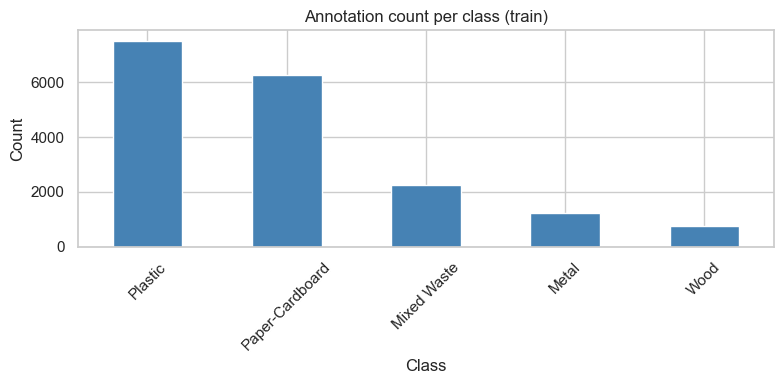

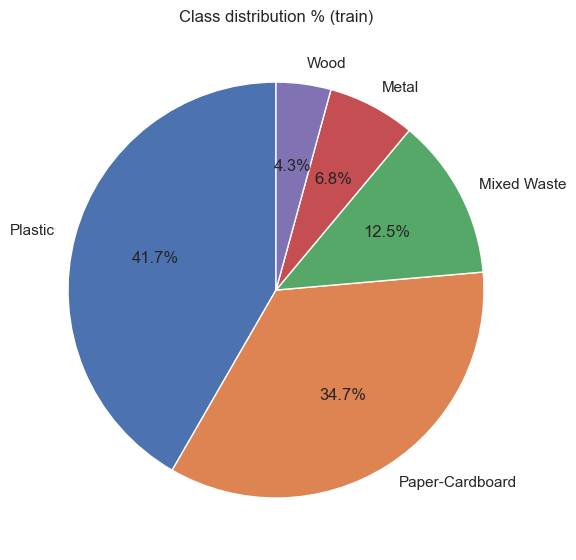

In [104]:
# Build annotation dataframe
cat_map = {c['id']: c['name'] for c in train_data['categories']}
df = pd.DataFrame(train_data['annotations'])
df['class_name'] = df['category_id'].map(cat_map)
df['bbox_area']  = df['bbox'].apply(lambda b: b[2] * b[3])

print('Annotation count per class:')
print(df['class_name'].value_counts())

# Bar chart
plt.figure(figsize=(8, 4))
df['class_name'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Annotation count per class (train)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart
total_ann = len(df)
class_pct = (df['class_name'].value_counts() / total_ann * 100).round(2)
plt.figure(figsize=(6, 6))
class_pct.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Class distribution % (train)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 4. Image Quality Analysis — Sample Images
Visualize one sample image per class to inspect visual quality and content.

Sample image per class:
  Plastic: 2024-09-27_14-40-00-757_jpeg_jpg.rf.400fb608b10914509c336d5c6a6b21b8.jpg
  Paper-Cardboard: 2024-09-27_14-40-00-757_jpeg_jpg.rf.400fb608b10914509c336d5c6a6b21b8.jpg
  Mixed Waste: 2024-09-27_14-40-00-757_jpeg_jpg.rf.400fb608b10914509c336d5c6a6b21b8.jpg
  Metal: 2024-09-02_15-10-01-066_jpeg_jpg.rf.f95a4f10471fed6ec45f6bb04359b50b.jpg
  Wood: 2024-09-27_17-40-00-752_jpeg_jpg.rf.2cca50cb14af8c8b2ed77dd3e96f80d8.jpg


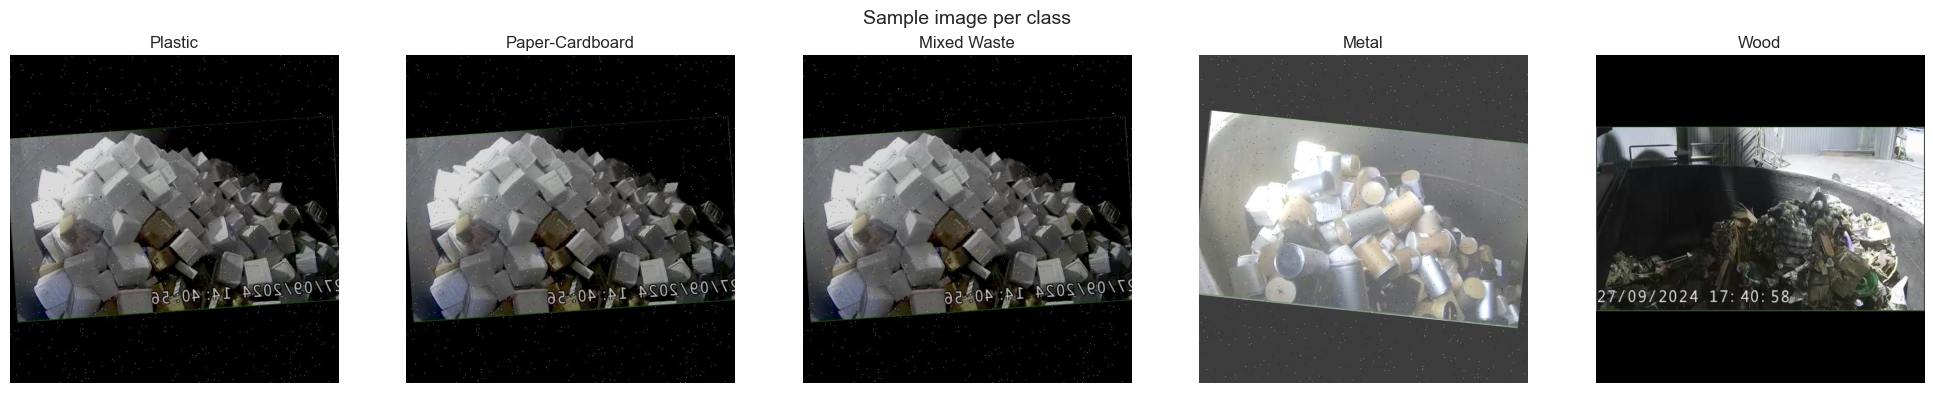

In [105]:
import cv2

TRAIN_IMG_DIR = '../data/raw/train'

# Map image id to filename
img_map = {img['id']: img['file_name'] for img in train_data['images']}

# Get one sample image per class
samples = {}
for ann in train_data['annotations']:
    cls = cat_map[ann['category_id']]
    if cls not in samples:
        samples[cls] = img_map[ann['image_id']]

print('Sample image per class:')
for cls, fname in samples.items():
    print(f'  {cls}: {fname}')

# Plot one image per class
n_classes = len(samples)
fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 4))

for ax, (cls, fname) in zip(axes, samples.items()):
    img_path = os.path.join(TRAIN_IMG_DIR, fname)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

plt.suptitle('Sample image per class', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Image Quality Analysis - Size & Resolution
Check image dimensions across all train images. Verify consistency of resolution.

In [106]:
# Read actual image dimensions from disk
sizes = []
for img in train_data['images']:
    img_path = os.path.join(TRAIN_IMG_DIR, img['file_name'])
    im = cv2.imread(img_path)
    if im is not None:
        h, w = im.shape[:2]
        sizes.append({'file': img['file_name'], 'width': w, 'height': h})

size_df = pd.DataFrame(sizes)

# Show unique resolutions and their counts
print('Unique resolutions found:')
print(size_df.groupby(['width', 'height']).size().reset_index(name='count'))

# Warn if mixed sizes detected
if size_df[['width', 'height']].nunique().max() == 1:
    print('\nAll images are the same size - consistent')
else:
    print('\nWarning: mixed image sizes detected - may need resizing before training')

Unique resolutions found:
   width  height  count
0    640     640   1008

All images are the same size - consistent


## 6. Image Quality Analysis - Lighting
Measure mean brightness per image using grayscale conversion. Flag dark images below threshold.

Brightness — min: 15.0
Brightness — max: 159.4
Brightness — mean: 68.2


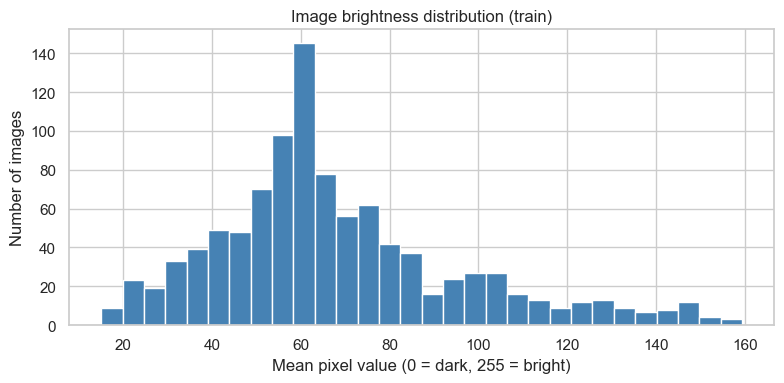


Dark images (brightness < 50): 234
                                                 file  brightness
0   2024-09-27_14-40-00-757_jpeg_jpg.rf.400fb608b1...   44.329851
22  2024-10-01_13-10-00-924_jpeg_jpg.rf.4972a87302...   40.761084
28  2024-09-28_17-00-00-939_jpeg_jpg.rf.52e5b277cd...   41.999509
57  2024-08-12_15-00-00-862_jpeg_jpg.rf.78a49357e7...   35.680974
59  2024-08-10_23-28-37-738_jpeg_jpg.rf.a5695dacc3...   43.167407


In [107]:
# Calculate mean brightness for each image using grayscale conversion
brightness = []
for img in train_data['images']:
    img_path = os.path.join(TRAIN_IMG_DIR, img['file_name'])
    im = cv2.imread(img_path)
    if im is not None:
        gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
        brightness.append({'file': img['file_name'], 'brightness': gray.mean()})

bright_df = pd.DataFrame(brightness)

# Summary statistics
print(f'Brightness — min: {bright_df["brightness"].min():.1f}')
print(f'Brightness — max: {bright_df["brightness"].max():.1f}')
print(f'Brightness — mean: {bright_df["brightness"].mean():.1f}')

# Plot brightness distribution
plt.figure(figsize=(8, 4))
plt.hist(bright_df['brightness'], bins=30, color='steelblue', edgecolor='white')
plt.title('Image brightness distribution (train)')
plt.xlabel('Mean pixel value (0 = dark, 255 = bright)')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

# Flag potentially dark images that may affect model performance
dark_images = bright_df[bright_df['brightness'] < 50]
print(f'\nDark images (brightness < 50): {len(dark_images)}')
print(dark_images.head())

## 7. Class Distribution Summary
Calculate annotation count and percentage per class. Identify dominant and minority classes.

In [108]:
# Calculate class distribution percentage
class_counts = df['class_name'].value_counts()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

print('Class distribution:')
for cls, cnt, pct in zip(class_counts.index, class_counts.values, class_pct.values):
    print(f'  {cls:<20} {cnt:>6} annotations  ({pct}%)')

Class distribution:
  Plastic                7511 annotations  (41.68%)
  Paper-Cardboard        6254 annotations  (34.7%)
  Mixed Waste            2262 annotations  (12.55%)
  Metal                  1227 annotations  (6.81%)
  Wood                    767 annotations  (4.26%)


## 8. Dominant & Minority Class
Compute imbalance ratio between dominant and minority class. Flag if severe imbalance detected.

In [109]:
# Identify dominant and minority classes
dominant = class_counts.idxmax()
minority = class_counts.idxmin()
imbalance_ratio = class_counts.max() / class_counts.min()

print(f'Dominant class : {dominant} ({class_counts[dominant]} annotations)')
print(f'Minority class : {minority} ({class_counts[minority]} annotations)')
print(f'Imbalance ratio: {imbalance_ratio:.1f}x')

if imbalance_ratio > 5:
    print('Warning: severe class imbalance detected — consider class weighting during training')

Dominant class : Plastic (7511 annotations)
Minority class : Wood (767 annotations)
Imbalance ratio: 9.8x


## 9. Imbalance Visualization
Bar chart highlighting dominant class in red for quick visual reference.

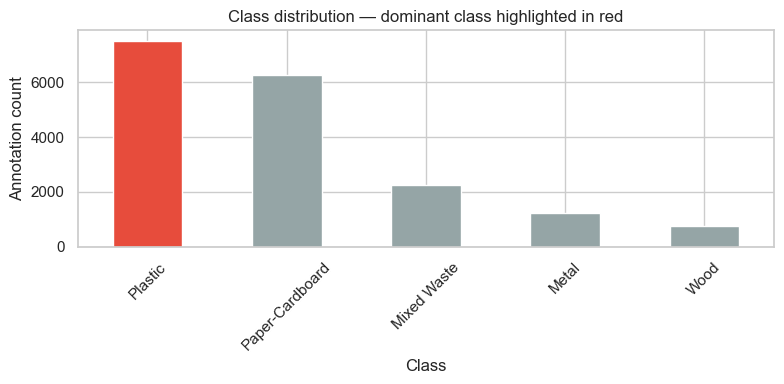

In [110]:
# Visualize imbalance — dominant class highlighted in red
plt.figure(figsize=(8, 4))
colors = ['#e74c3c' if c == dominant else '#95a5a6' for c in class_counts.index]
class_counts.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Class distribution — dominant class highlighted in red')
plt.xlabel('Class')
plt.ylabel('Annotation count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Images Per Class
Count how many unique images contain each class. Distinct from annotation count.

In [111]:
# Count unique images containing each class
images_per_class = {}
for cls in cat_map.values():
    if cls == 'wastes':
        continue
    count = df[df['class_name'] == cls]['image_id'].nunique()
    images_per_class[cls] = count

print('Number of images containing each class:')
for cls, cnt in sorted(images_per_class.items(), key=lambda x: -x[1]):
    print(f'  {cls:<20} {cnt} images')

Number of images containing each class:
  Mixed Waste          870 images
  Plastic              519 images
  Paper-Cardboard      477 images
  Wood                 261 images
  Metal                48 images


## 11. Single vs Multiple Classes Per Image
Check how many images contain only one class vs multiple classes simultaneously.

Images with single class     : 291
Images with multiple classes : 672


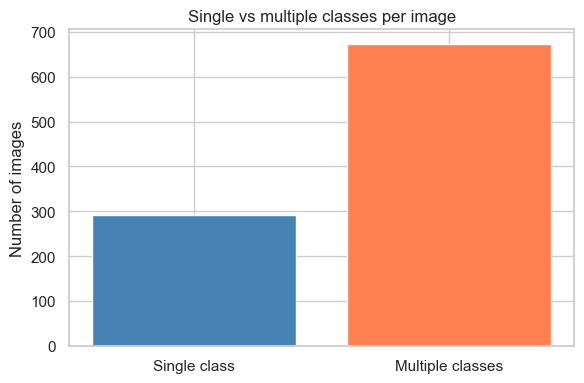

In [112]:
# Check how many images have only one class vs multiple classes
df_img_classes = df.groupby('image_id')['class_name'].nunique()

single_class = (df_img_classes == 1).sum()
multi_class  = (df_img_classes > 1).sum()

print(f'Images with single class     : {single_class}')
print(f'Images with multiple classes : {multi_class}')

plt.figure(figsize=(6, 4))
plt.bar(['Single class', 'Multiple classes'], [single_class, multi_class],
        color=['steelblue', 'coral'], edgecolor='white')
plt.title('Single vs multiple classes per image')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

## 12. Bbox Area Histogram Per Class
Distribution of bounding box area per class using histogram to understand object size range.

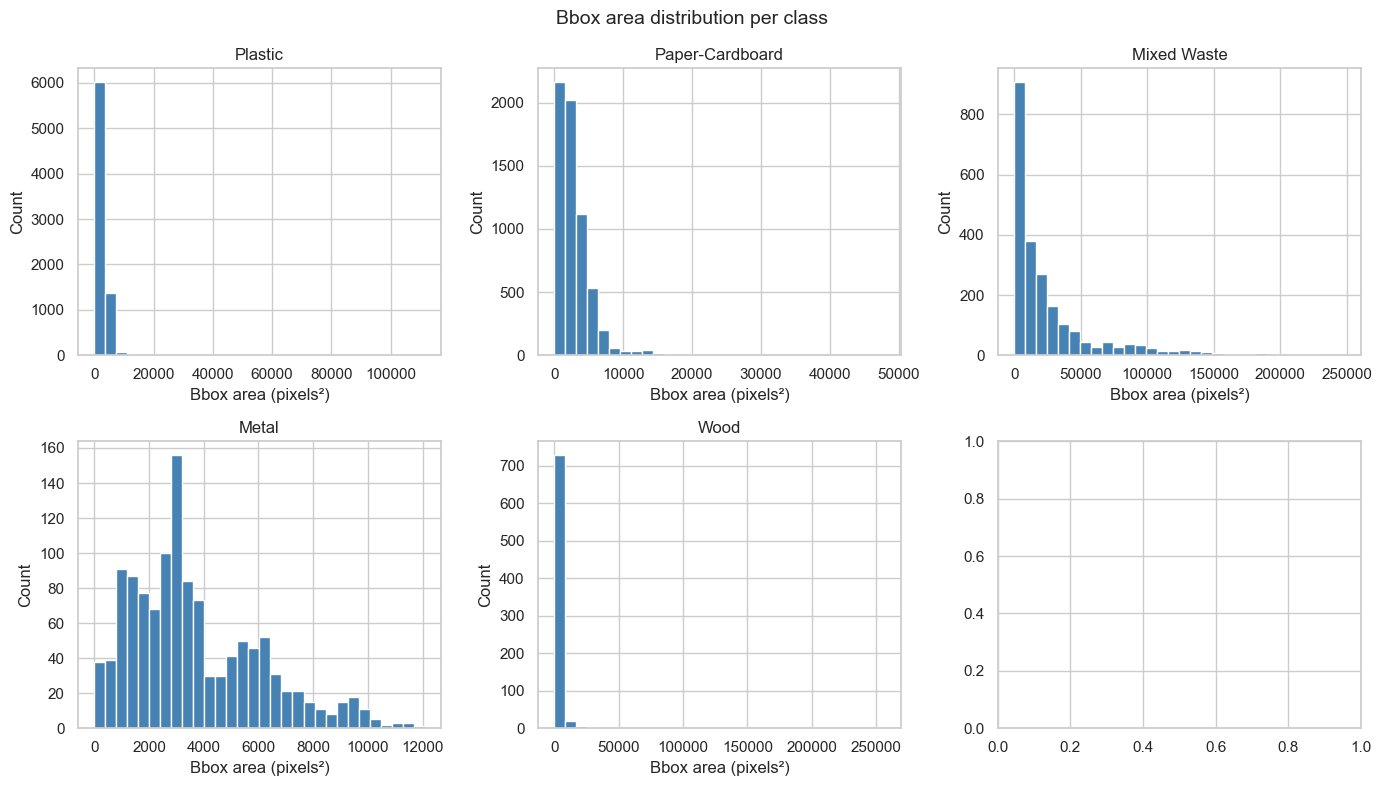

In [113]:
# Plot bbox area distribution per class using histogram
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cls in enumerate(df['class_name'].unique()):
    if cls == 'wastes':
        continue
    subset = df[df['class_name'] == cls]['bbox_area']
    axes[i].hist(subset, bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{cls}')
    axes[i].set_xlabel('Bbox area (pixels²)')
    axes[i].set_ylabel('Count')

plt.suptitle('Bbox area distribution per class', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Bbox Area Boxplot Per Class
Boxplot comparison of bbox area across classes to identify spread and outliers.

C:\Users\bhumi\AppData\Local\Temp\ipykernel_3548\1569275534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['class_name'] != 'wastes'],


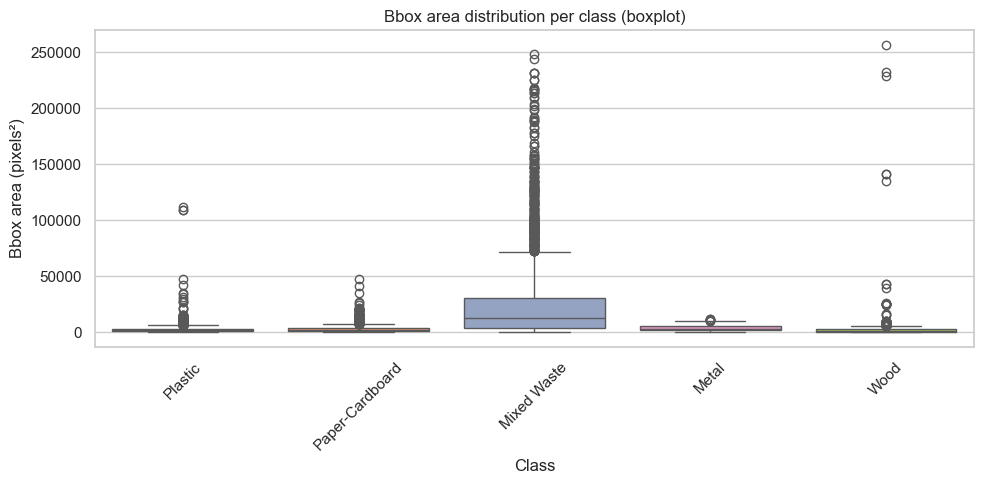

In [114]:
# Boxplot to compare spread and outliers across classes
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['class_name'] != 'wastes'],
            x='class_name', y='bbox_area', palette='Set2')
plt.title('Bbox area distribution per class (boxplot)')
plt.xlabel('Class')
plt.ylabel('Bbox area (pixels²)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Summary Statistics Per Class
Descriptive statistics (mean, std, min, max, quartiles) of bbox area per class.

In [115]:
# Descriptive statistics per class
summary = df[df['class_name'] != 'wastes'].groupby('class_name')['bbox_area'].describe().round(2)
print('Summary statistics of bbox area per class:')
print(summary)

Summary statistics of bbox area per class:
                  count      mean       std   min      25%       50%  \
class_name                                                             
Metal            1227.0   3692.64   2379.32  0.36  1882.82   3120.00   
Mixed Waste      2262.0  27084.77  38082.67  0.41  3557.04  12622.46   
Paper-Cardboard  6254.0   2914.92   2689.60  0.21  1246.75   2193.78   
Plastic          7511.0   2455.86   3083.92  0.02  1014.00   1842.73   
Wood              767.0   3887.39  17568.56  0.37   574.91   1188.00   

                      75%        max  
class_name                            
Metal             5299.50   12072.98  
Mixed Waste      31102.27  248217.73  
Paper-Cardboard   3811.99   47915.09  
Plastic           3252.38  111487.91  
Wood              2712.99  256540.18  


## 15. Check Filename Format
Inspect image filenames to confirm date and time information is available for time-series analysis.

In [116]:
# Check first 10 image filenames to see if date info is available
for img in train_data['images'][:10]:
    print(img['file_name'])

2024-09-27_14-40-00-757_jpeg_jpg.rf.400fb608b10914509c336d5c6a6b21b8.jpg
2024-08-14_10-00-00-299_jpeg_jpg.rf.8356a604583ffd98aa5099d30e1e6dff.jpg
2024-09-03_10-40-00-109_jpeg_jpg.rf.eb35db176fd7b2634b7d58af784ada05.jpg
2024-09-02_15-10-01-066_jpeg_jpg.rf.f95a4f10471fed6ec45f6bb04359b50b.jpg
2024-09-27_17-50-00-748_jpeg_jpg.rf.9f6a4ea20e08d0e4d297dc9fb8212a54.jpg
2024-09-27_14-40-00-757_jpeg_jpg.rf.624ea4873f6bba1e489821dabd21beb5.jpg
2024-09-27_17-00-00-757_jpeg_jpg.rf.3f088d00bd696996b31e2d9b28c8bfb9.jpg
2024-09-27_17-40-00-752_jpeg_jpg.rf.2cca50cb14af8c8b2ed77dd3e96f80d8.jpg
2024-09-17_15-03-18-979_jpeg_jpg.rf.e602ab75f951a89b8d68d4dd1e8466bc.jpg
2024-08-26_13-00-00-135_jpeg_jpg.rf.8756d639ac8c168f59f85126441451de.jpg


## 16. Parse Date from Filename
Extract datetime from filename format YYYY-MM-DD_HH-MM-SS. Add date column to image dataframe.

In [117]:
import re

# Parse date from filename format: YYYY-MM-DD_HH-MM-SS
def parse_date(filename):
    match = re.match(r'(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})', filename)
    if match:
        date_str = match.group(1)
        time_str = match.group(2).replace('-', ':')
        return pd.to_datetime(f'{date_str} {time_str}')
    return None

# Add datetime to image dataframe
img_df = pd.DataFrame(train_data['images'])
img_df['datetime'] = img_df['file_name'].apply(parse_date)
img_df['date'] = img_df['datetime'].dt.date

print('Date range:')
print(f'  Earliest : {img_df["date"].min()}')
print(f'  Latest   : {img_df["date"].max()}')
print(f'  Total days: {(img_df["date"].max() - img_df["date"].min()).days}')
print(f'\nSample:')
print(img_df[['file_name', 'datetime', 'date']].head(5))

Date range:
  Earliest : 2024-08-07
  Latest   : 2024-10-01
  Total days: 55

Sample:
                                           file_name            datetime  \
0  2024-09-27_14-40-00-757_jpeg_jpg.rf.400fb608b1... 2024-09-27 14:40:00   
1  2024-08-14_10-00-00-299_jpeg_jpg.rf.8356a60458... 2024-08-14 10:00:00   
2  2024-09-03_10-40-00-109_jpeg_jpg.rf.eb35db176f... 2024-09-03 10:40:00   
3  2024-09-02_15-10-01-066_jpeg_jpg.rf.f95a4f1047... 2024-09-02 15:10:01   
4  2024-09-27_17-50-00-748_jpeg_jpg.rf.9f6a4ea20e... 2024-09-27 17:50:00   

         date  
0  2024-09-27  
1  2024-08-14  
2  2024-09-03  
3  2024-09-02  
4  2024-09-27  


## 17. Daily Annotation Count Per Class
Merge annotations with image dates. Aggregate annotation count per class per day.

In [118]:
# Merge annotations with image datetime
df_time = df.merge(img_df[['id', 'date']], left_on='image_id', right_on='id', how='left')
df_time = df_time[df_time['class_name'] != 'wastes']

# Count annotations per class per day
daily = df_time.groupby(['date', 'class_name']).size().unstack(fill_value=0)
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()

print('Daily annotation count per class (first 5 days):')
print(daily.head())

Daily annotation count per class (first 5 days):
class_name  Metal  Mixed Waste  Paper-Cardboard  Plastic  Wood
date                                                          
2024-08-07      0           72               81       39     0
2024-08-08      0           57               81       66     0
2024-08-09      0           24              174      117    92
2024-08-10      0           48                0       99    54
2024-08-11      0           24                0        0    15


## 18. Daily Trend Plot
Line chart showing daily annotation count trend for each class over the full 55-day period.

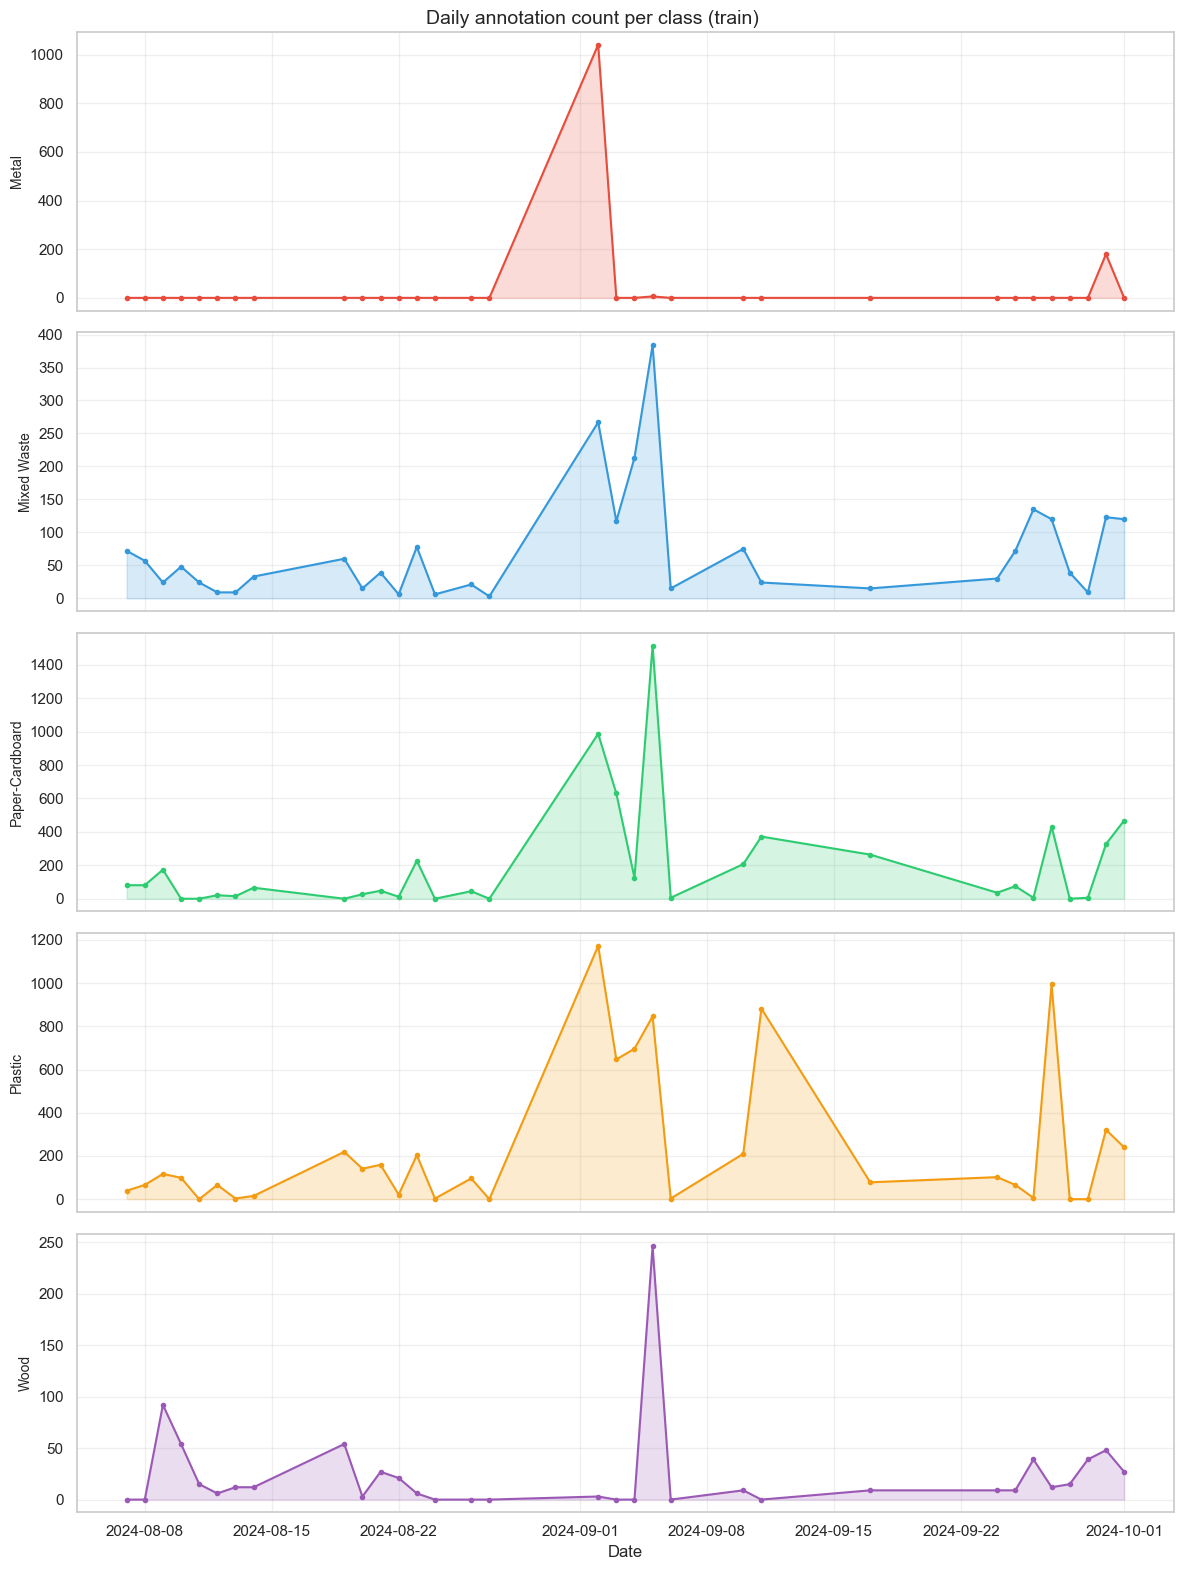

In [119]:
# Plot daily trend for each class
fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)

classes = [c for c in daily.columns if c != 'wastes']
colors  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for ax, cls, color in zip(axes, classes, colors):
    ax.plot(daily.index, daily[cls], color=color, linewidth=1.5, marker='o', markersize=3)
    ax.fill_between(daily.index, daily[cls], alpha=0.2, color=color)
    ax.set_ylabel(cls, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.suptitle('Daily annotation count per class (train)', fontsize=14)
plt.tight_layout()
plt.show()

## 19. Weekly Trend
Resample daily data to weekly sum. Visualize and print weekly annotation count per class.

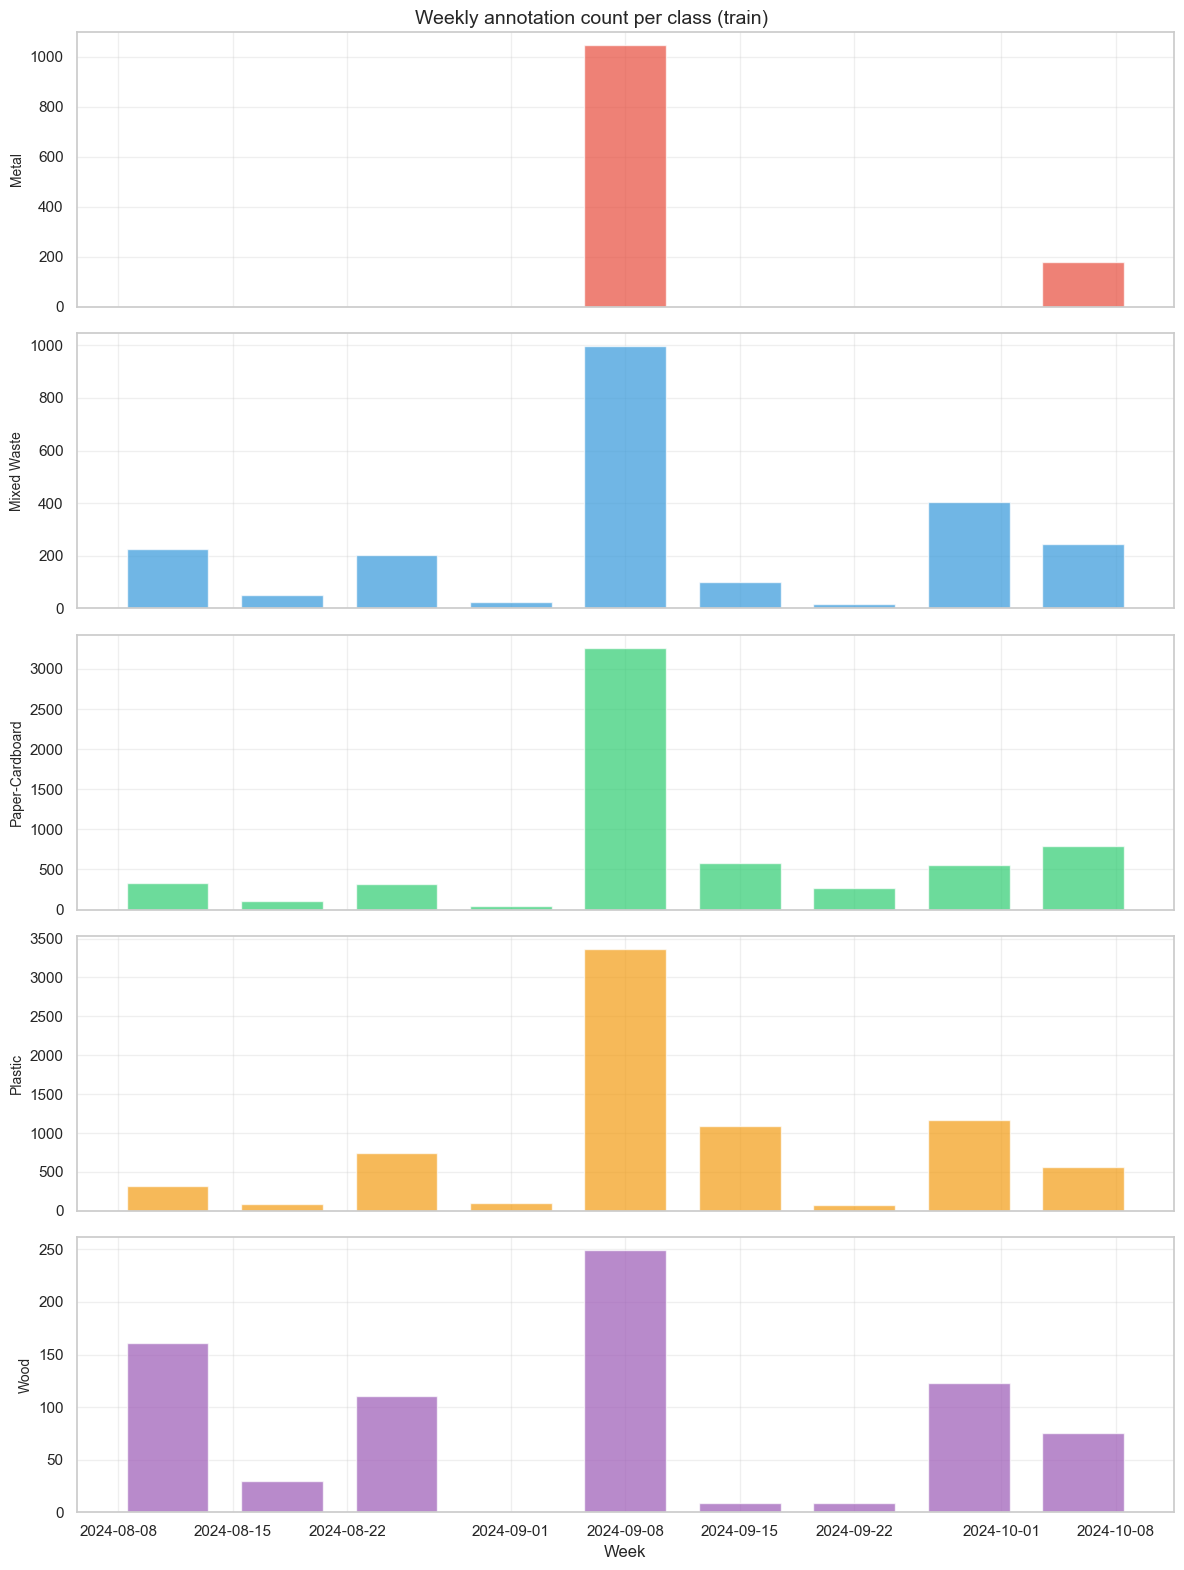

Weekly annotation count per class:
class_name  Metal  Mixed Waste  Paper-Cardboard  Plastic  Wood
date                                                          
2024-08-11      0          225              336      321   161
2024-08-18      0           51              102       84    30
2024-08-25      0          204              314      747   111
2024-09-01      0           24               45       96     0
2024-09-08   1047          996             3264     3364   249
2024-09-15      0           99              579     1092     9
2024-09-22      0           15              264       78     9
2024-09-29      0          405              555     1168   123
2024-10-06    180          243              795      561    75


In [120]:
# Resample daily data to weekly sum
weekly = daily.resample('W').sum()

fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
classes = [c for c in weekly.columns if c != 'wastes']
colors  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for ax, cls, color in zip(axes, classes, colors):
    ax.bar(weekly.index, weekly[cls], color=color, alpha=0.7, width=5)
    ax.set_ylabel(cls, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Week')
plt.suptitle('Weekly annotation count per class (train)', fontsize=14)
plt.tight_layout()
plt.show()

# Print weekly numbers
print('Weekly annotation count per class:')
print(weekly)

## 20. Monthly Trend
Resample to monthly sum. Useful for understanding overall volume across August, September, October.

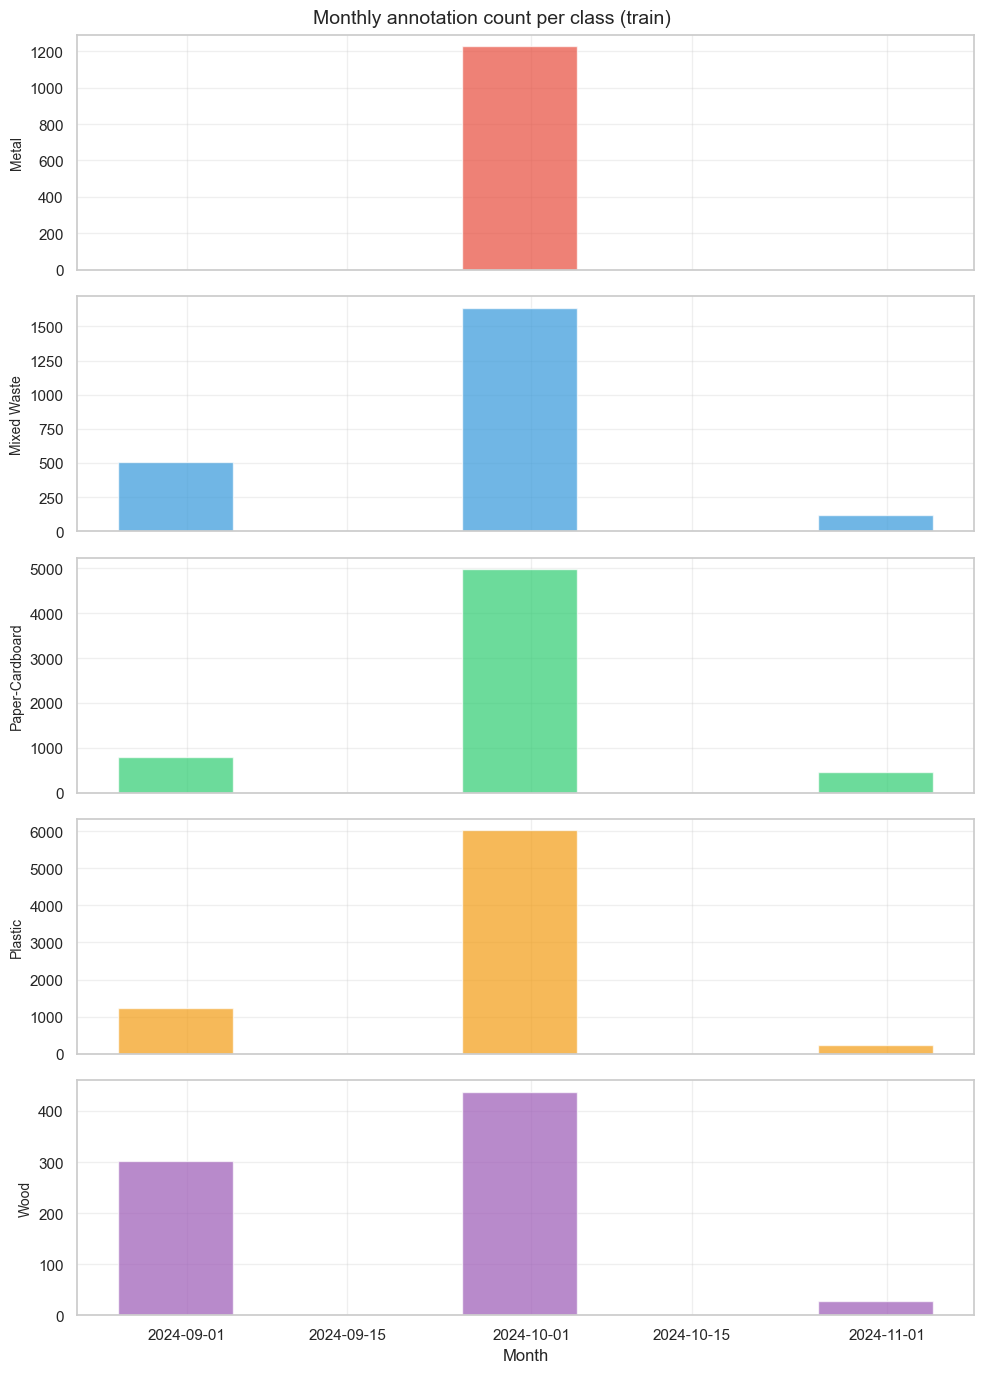

Monthly annotation count per class:
class_name  Metal  Mixed Waste  Paper-Cardboard  Plastic  Wood
date                                                          
2024-08-31      0          504              797     1248   302
2024-09-30   1227         1638             4989     6023   438
2024-10-31      0          120              468      240    27


In [121]:
# Resample to monthly sum
monthly = daily.resample('ME').sum()

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

for ax, cls, color in zip(axes, classes, colors):
    ax.bar(monthly.index, monthly[cls], color=color, alpha=0.7, width=10)
    ax.set_ylabel(cls, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Month')
plt.suptitle('Monthly annotation count per class (train)', fontsize=14)
plt.tight_layout()
plt.show()

# Print monthly numbers
print('Monthly annotation count per class:')
print(monthly)

## 21. Correlation Matrix
Pivot annotations by image and class. Compute Pearson correlation between classes.

In [122]:
# Count annotations per class per image (pivot table)
img_class_pivot = df[df['class_name'] != 'wastes'].groupby(
    ['image_id', 'class_name']
).size().unstack(fill_value=0)

# Pearson correlation between classes
corr_matrix = img_class_pivot.corr()

print('Correlation matrix:')
print(corr_matrix.round(2))

Correlation matrix:
class_name       Metal  Mixed Waste  Paper-Cardboard  Plastic  Wood
class_name                                                         
Metal             1.00         0.03            -0.04     0.07 -0.08
Mixed Waste       0.03         1.00             0.19     0.14  0.09
Paper-Cardboard  -0.04         0.19             1.00     0.31 -0.05
Plastic           0.07         0.14             0.31     1.00 -0.03
Wood             -0.08         0.09            -0.05    -0.03  1.00


## 22. Correlation Heatmap
Visualize correlation matrix as heatmap. Higher values indicate classes that co-occur more often.

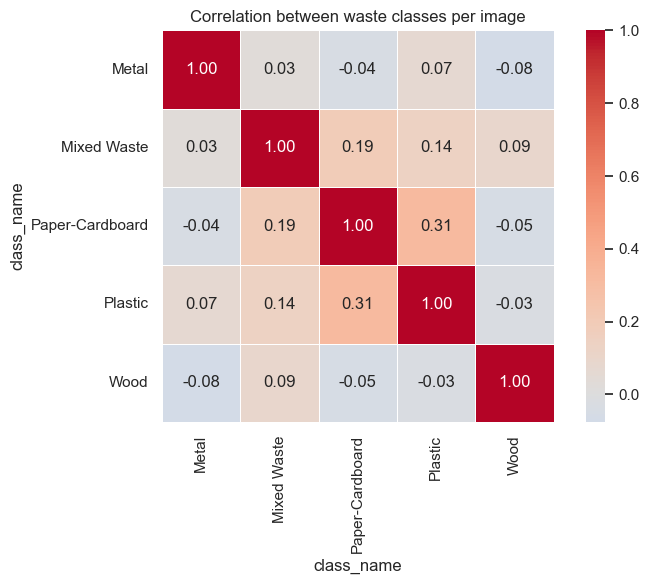

In [123]:
# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation between waste classes per image')
plt.tight_layout()
plt.show()

## 23. Top Correlated Pairs
Rank all class pairs by correlation coefficient to identify strongest co-occurrence relationships.

In [124]:
# Extract upper triangle to avoid duplicate pairs
import itertools

pairs = []
classes_list = corr_matrix.columns.tolist()

for c1, c2 in itertools.combinations(classes_list, 2):
    pairs.append({
        'class_1': c1,
        'class_2': c2,
        'correlation': corr_matrix.loc[c1, c2]
    })

pairs_df = pd.DataFrame(pairs).sort_values('correlation', ascending=False)

print('Class pairs ranked by correlation:')
print(pairs_df.to_string(index=False))

Class pairs ranked by correlation:
        class_1         class_2  correlation
Paper-Cardboard         Plastic     0.313541
    Mixed Waste Paper-Cardboard     0.190361
    Mixed Waste         Plastic     0.141365
    Mixed Waste            Wood     0.091304
          Metal         Plastic     0.066347
          Metal     Mixed Waste     0.027869
        Plastic            Wood    -0.026937
          Metal Paper-Cardboard    -0.044223
Paper-Cardboard            Wood    -0.050151
          Metal            Wood    -0.075527


## 24. Daily Total + IQR Outlier Detection
Calculate total annotations per day. Apply IQR method to detect statistically anomalous days.

In [125]:
# Calculate total annotations per day across all classes
daily_total = daily.sum(axis=1)

# IQR method
Q1  = daily_total.quantile(0.25)
Q3  = daily_total.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_days = daily_total[(daily_total < lower) | (daily_total > upper)]

print(f'Q1: {Q1:.1f}  Q3: {Q3:.1f}  IQR: {IQR:.1f}')
print(f'Lower bound: {lower:.1f}')
print(f'Upper bound: {upper:.1f}')
print(f'\nOutlier days detected: {len(outlier_days)}')
print(outlier_days.sort_values(ascending=False))

Q1: 91.5  Q3: 600.0  IQR: 508.5
Lower bound: -671.2
Upper bound: 1362.8

Outlier days detected: 4
date
2024-09-02    3470
2024-09-05    2997
2024-09-27    1558
2024-09-03    1394
dtype: int64


## 25. Outlier Day Visualization
Plot daily total annotation count with IQR bounds and highlight detected outlier days.

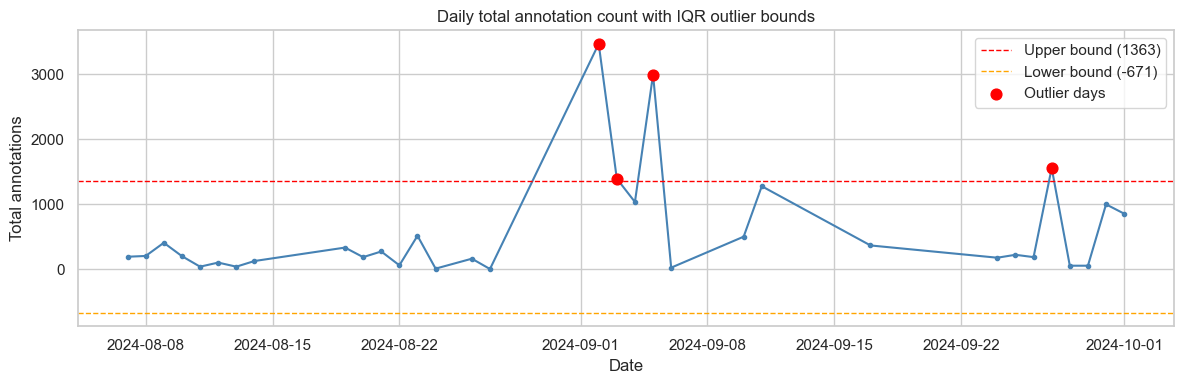

In [126]:
# Plot daily total with outlier days highlighted
plt.figure(figsize=(12, 4))
plt.plot(daily_total.index, daily_total.values, color='steelblue', linewidth=1.5, marker='o', markersize=3)
plt.axhline(y=upper, color='red',    linestyle='--', linewidth=1, label=f'Upper bound ({upper:.0f})')
plt.axhline(y=lower, color='orange', linestyle='--', linewidth=1, label=f'Lower bound ({lower:.0f})')

# Highlight outlier days
plt.scatter(outlier_days.index, outlier_days.values, color='red', zorder=5, s=60, label='Outlier days')

plt.title('Daily total annotation count with IQR outlier bounds')
plt.xlabel('Date')
plt.ylabel('Total annotations')
plt.legend()
plt.tight_layout()
plt.show()

## 26. Per-Class IQR Outlier Detection
Apply IQR outlier detection independently for each class to identify class-specific anomalous days.

In [127]:
# Detect outlier days per class individually
print('Outlier days per class:')
for cls in daily.columns:
    series = daily[cls]
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    out    = series[(series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)]
    if len(out) > 0:
        print(f'\n  {cls} — {len(out)} outlier day(s):')
        print(out.sort_values(ascending=False).to_string())

Outlier days per class:

  Metal — 3 outlier day(s):
date
2024-09-02    1041
2024-09-30     180
2024-09-05       6

  Mixed Waste — 3 outlier day(s):
date
2024-09-05    384
2024-09-02    267
2024-09-04    213

  Paper-Cardboard — 3 outlier day(s):
date
2024-09-05    1515
2024-09-02     987
2024-09-03     630

  Plastic — 6 outlier day(s):
date
2024-09-02    1172
2024-09-27     994
2024-09-11     882
2024-09-05     846
2024-09-04     696
2024-09-03     647

  Wood — 2 outlier day(s):
date
2024-09-05    246
2024-08-09     92


## 27. Split Data into Time Periods
Divide dataset into August vs Sep-Oct periods for comparative statistical testing.

In [128]:
# Split into early (Aug) vs late (Sep-Oct) period
df_time['month'] = pd.to_datetime(df_time['date']).dt.month
df_time['period'] = df_time['month'].apply(lambda x: 'August' if x == 8 else 'Sep-Oct')

print('Annotation count by period:')
print(df_time.groupby(['period', 'class_name']).size().unstack(fill_value=0))

Annotation count by period:
class_name  Metal  Mixed Waste  Paper-Cardboard  Plastic  Wood
period                                                        
August          0          504              797     1248   302
Sep-Oct      1227         1758             5457     6263   465


## 28. Kruskal-Wallis Test - Bbox Area Across Classes
Non-parametric test to determine if bbox area differs significantly across waste classes.

In [129]:
# Test: does bbox area differ significantly across classes?
groups = [df_time[df_time['class_name'] == cls]['bbox_area'].dropna().values
          for cls in df_time['class_name'].unique() if cls != 'wastes']

stat, p = stats.kruskal(*groups)
print(f'Kruskal-Wallis test (bbox area across classes)')
print(f'  H-statistic : {stat:.4f}')
print(f'  p-value     : {p:.6f}')
if p < 0.05:
    print('  Result: Significant difference in bbox area across classes (p < 0.05)')
else:
    print('  Result: No significant difference (p >= 0.05)')

Kruskal-Wallis test (bbox area across classes)
  H-statistic : 3040.7723
  p-value     : 0.000000
  Result: Significant difference in bbox area across classes (p < 0.05)


## 29. Mann-Whitney U Test - Early vs Late Period
Test whether each class composition changed significantly between August and September-October.

In [130]:
# Test: does each class composition differ between August vs Sep-Oct?
print('Mann-Whitney U test - August vs Sep-Oct per class:\n')

for cls in df_time['class_name'].unique():
    if cls == 'wastes':
        continue
    aug     = df_time[(df_time['class_name'] == cls) & (df_time['period'] == 'August')]['bbox_area'].dropna()
    sep_oct = df_time[(df_time['class_name'] == cls) & (df_time['period'] == 'Sep-Oct')]['bbox_area'].dropna()

    if len(aug) > 0 and len(sep_oct) > 0:
        stat, p = stats.mannwhitneyu(aug, sep_oct, alternative='two-sided')
        sig = 'significant' if p < 0.05 else 'not significant'
        print(f'  {cls:<20} U={stat:.0f}  p={p:.4f}  → {sig}')

Mann-Whitney U test - August vs Sep-Oct per class:

  Plastic              U=3738362  p=0.0152  → significant
  Paper-Cardboard      U=2214781  p=0.3989  → not significant
  Mixed Waste          U=530642  p=0.0000  → significant
  Wood                 U=88679  p=0.0000  → significant


## 30. Mann-Whitney U Test - Normal vs Outlier Days
Statistically confirm whether outlier days differ significantly from normal days in annotation volume.

In [131]:
# Test: does daily annotation count differ significantly between outlier days and normal days?
outlier_dates  = outlier_days.index.tolist()
df_time['is_outlier'] = pd.to_datetime(df_time['date']).isin(outlier_dates)

normal_count  = df_time[~df_time['is_outlier']].groupby('date').size()
outlier_count = df_time[ df_time['is_outlier']].groupby('date').size()

stat, p = stats.mannwhitneyu(normal_count, outlier_count, alternative='two-sided')
print(f'Mann-Whitney U test - normal days vs outlier days')
print(f'  Normal days  mean: {normal_count.mean():.1f}  n={len(normal_count)}')
print(f'  Outlier days mean: {outlier_count.mean():.1f}  n={len(outlier_count)}')
print(f'  U={stat:.0f}  p={p:.4f}')
if p < 0.05:
    print('  Result: Outlier days are statistically different from normal days (p < 0.05)')
else:
    print('  Result: No significant difference (p >= 0.05)')

Mann-Whitney U test - normal days vs outlier days
  Normal days  mean: 307.2  n=28
  Outlier days mean: 2354.8  n=4
  U=0  p=0.0016
  Result: Outlier days are statistically different from normal days (p < 0.05)


## 31. Distribution Fitting
Fit five candidate distributions (norm, lognorm, expon, gamma, weibull_min) to bbox area per class using KS test.

In [132]:
from scipy import stats as st

# Distributions to test
distributions = {
    'norm'    : st.norm,
    'lognorm' : st.lognorm,
    'expon'   : st.expon,
    'gamma'   : st.gamma,
    'weibull_min': st.weibull_min
}

classes_to_fit = [c for c in df['class_name'].unique() if c != 'wastes']
results = []

for cls in classes_to_fit:
    data = df[df['class_name'] == cls]['bbox_area'].dropna().values
    for dist_name, dist in distributions.items():
        try:
            params = dist.fit(data)
            ks_stat, ks_p = st.kstest(data, dist_name, args=params)
            results.append({
                'class'       : cls,
                'distribution': dist_name,
                'ks_stat'     : round(ks_stat, 4),
                'ks_p_value'  : round(ks_p, 4),
                'good_fit'    : ks_p > 0.05
            })
        except Exception as e:
            pass

results_df = pd.DataFrame(results)
print('Distribution fitting results (KS test):')
print(results_df.to_string(index=False))

Distribution fitting results (KS test):
          class distribution  ks_stat  ks_p_value  good_fit
        Plastic         norm   0.2194      0.0000     False
        Plastic      lognorm   0.0217      0.0016     False
        Plastic        expon   0.1161      0.0000     False
        Plastic        gamma   0.9987      0.0000     False
        Plastic  weibull_min   0.6703      0.0000     False
Paper-Cardboard         norm   0.1525      0.0000     False
Paper-Cardboard      lognorm   0.0190      0.0212     False
Paper-Cardboard        expon   0.1232      0.0000     False
Paper-Cardboard        gamma   0.9981      0.0000     False
Paper-Cardboard  weibull_min   0.0498      0.0000     False
    Mixed Waste         norm   0.2384      0.0000     False
    Mixed Waste      lognorm   0.0454      0.0002     False
    Mixed Waste        expon   0.1422      0.0000     False
    Mixed Waste        gamma   0.0578      0.0000     False
    Mixed Waste  weibull_min   0.0351      0.0074     False


## 32. Best Fit Per Class
Select the best fitting distribution per class based on highest KS test p-value.

In [133]:
# Find best fitting distribution per class (highest p-value)
print('Best fit distribution per class:\n')
for cls in classes_to_fit:
    subset = results_df[results_df['class'] == cls].sort_values('ks_p_value', ascending=False)
    best   = subset.iloc[0]
    print(f'  {cls:<20} → {best["distribution"]:<12} (KS={best["ks_stat"]}, p={best["ks_p_value"]})')

Best fit distribution per class:

  Plastic              → lognorm      (KS=0.0217, p=0.0016)
  Paper-Cardboard      → lognorm      (KS=0.019, p=0.0212)
  Mixed Waste          → weibull_min  (KS=0.0351, p=0.0074)
  Metal                → gamma        (KS=0.0394, p=0.0431)
  Wood                 → lognorm      (KS=0.0402, p=0.1639)


## 33. Best Fit Visualization
Plot histogram of observed data overlaid with the best fit distribution curve per class.

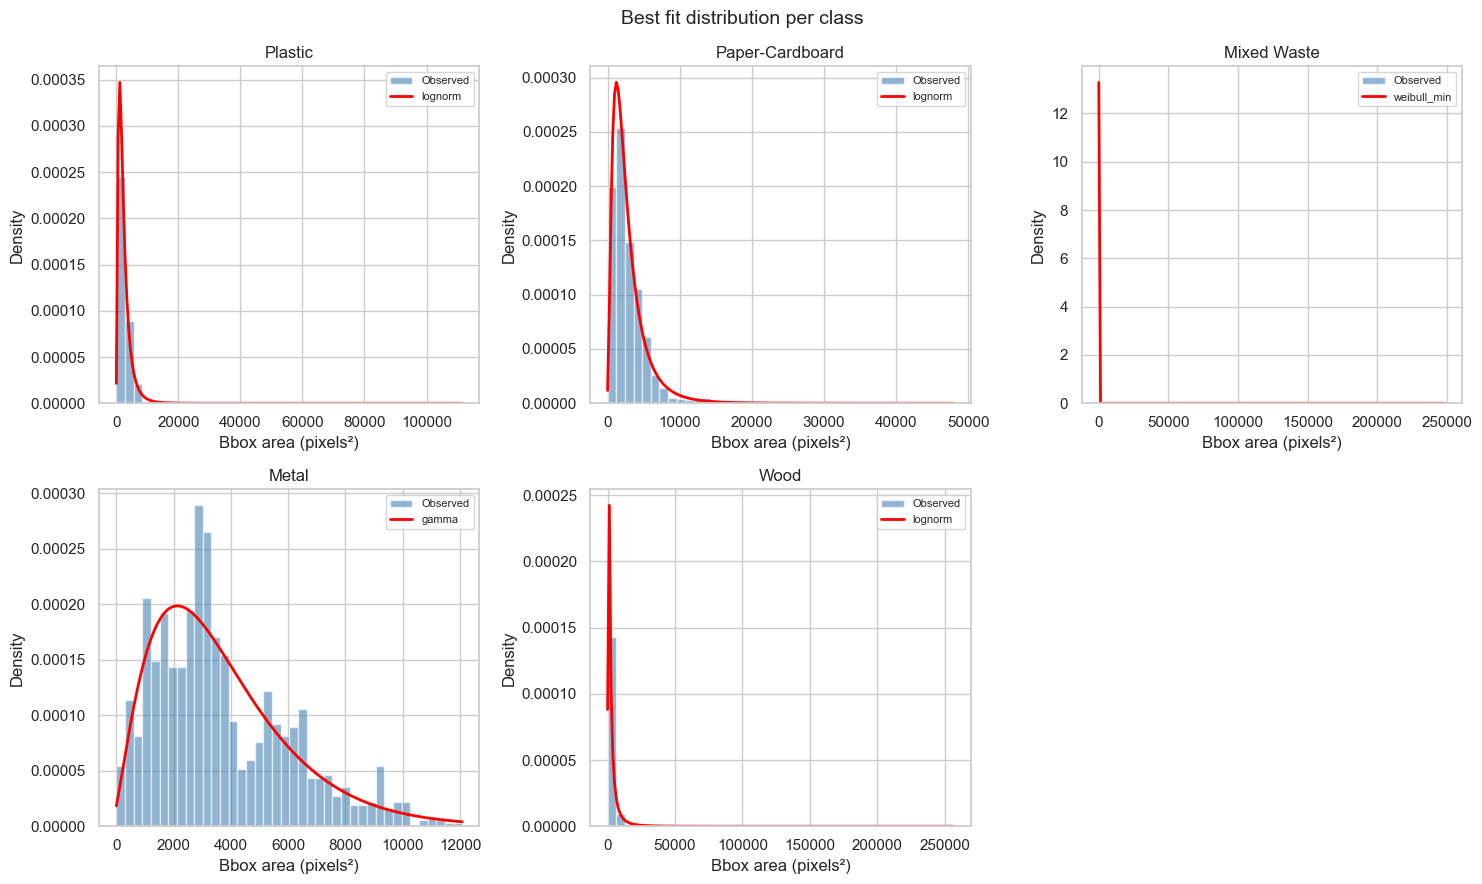

In [134]:
# Plot histogram vs best fit distribution for each class
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, cls in enumerate(classes_to_fit):
    data   = df[df['class_name'] == cls]['bbox_area'].dropna().values
    subset = results_df[results_df['class'] == cls].sort_values('ks_p_value', ascending=False)
    best_dist_name = subset.iloc[0]['distribution']
    best_dist      = distributions[best_dist_name]

    # Fit params
    params = best_dist.fit(data)

    # Plot histogram
    axes[i].hist(data, bins=40, density=True, color='steelblue',
                 alpha=0.6, edgecolor='white', label='Observed')

    # Plot fitted distribution
    x = np.linspace(data.min(), data.max(), 200)
    axes[i].plot(x, best_dist.pdf(x, *params), color='red',
                 linewidth=2, label=f'{best_dist_name}')

    axes[i].set_title(f'{cls}')
    axes[i].set_xlabel('Bbox area (pixels²)')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

# Hide unused subplot
for j in range(len(classes_to_fit), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Best fit distribution per class', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Business Insights & Operational Recommendations

### Finding 1 — Plastic is the dominant waste class (41.68%)
**Implication:** Plastic makes up nearly half of all waste by annotation count.  
**Recommendation:** Incineration settings should be optimized for plastic-heavy loads as the default configuration. Operators should be trained to recognize high-plastic batches visually.

### Finding 2 — Severe class imbalance (Plastic 9.8x more than Wood)
**Implication:** The AI model may underperform on minority classes (Wood, Metal) due to limited training examples.  
**Recommendation:** Apply class weighting during Mask R-CNN training. Consider collecting more images of Wood and Metal batches to improve model balance.

### Finding 3 — 23% of images are dark (brightness < 50)
**Implication:** Poor lighting conditions affect image quality and may reduce model accuracy during real deployment.  
**Recommendation:** Install adequate lighting above the waste bin or camera position. Apply brightness augmentation during training to improve robustness under low-light conditions.

### Finding 4 — Metal arrives sporadically, not daily
**Implication:** Metal waste does not follow a predictable daily pattern. It arrives in large batch events (e.g., 2024-09-02: 1,041 annotations in one day).  
**Recommendation:** Do not rely on daily Metal forecasts. Instead, monitor for Metal spike events and treat them as anomalies requiring special handling procedures.

### Finding 5 — Paper-Cardboard and Plastic tend to co-occur (correlation = 0.31)
**Implication:** These two waste types likely come from the same source (e.g., packaging waste from a specific supplier or department).  
**Recommendation:** Investigate whether a single waste source is responsible for combined Paper-Cardboard and Plastic loads. Coordinating with that source could help predict and prepare for high-volume days.

### Finding 6 — Outlier days (2024-09-02, 09-05) show anomalous volume across all classes
**Implication:** These days had 2,354 average annotations vs 307 on normal days — statistically confirmed as anomalous (p=0.0016).  
**Recommendation:** Flag these events in the system as large batch delivery days. The LLM alert module should automatically notify operators when daily volume exceeds the IQR upper bound (1,362 annotations).

### Finding 7 — Plastic and Wood composition shifted significantly between August and September
**Implication:** Waste composition is not stable over time — it changes between months, possibly due to seasonal production patterns or supplier changes.  
**Recommendation:** Retrain or fine-tune the forecasting model periodically (e.g., monthly) to account for composition drift. Do not assume a static waste profile.

### Finding 8 — Mixed Waste has the highest mean bbox area (27,084 pixels²)
**Implication:** Mixed Waste objects occupy significantly more image area than other classes, which may cause the model to overfit to large-area detections.  
**Recommendation:** During inference, use area-based post-processing to separate large Mixed Waste regions from smaller individual class detections.

### Finding 9 — Wood is the only class with a statistically good distribution fit (lognorm)
**Implication:** Wood has the most predictable size distribution, making it the most reliable class for statistical modeling and anomaly thresholding.  
**Recommendation:** Use Wood's lognorm distribution parameters to set anomaly detection thresholds for this class specifically.

### Summary Table

| Finding | Severity | Action Required |
|---|---|---|
| Plastic dominance (41.68%) | Medium | Optimize incineration for plastic-heavy loads |
| Class imbalance 9.8x | High | Apply class weighting in training |
| 23% dark images | Medium | Improve lighting, add augmentation |
| Metal sporadic arrivals | High | Treat Metal as event-based anomaly |
| Paper + Plastic co-occurrence | Low | Investigate shared waste source |
| Outlier batch days confirmed | High | Automate alert when volume > 1,362 |
| Composition drift Aug→Sep | Medium | Retrain forecasting model monthly |
| Mixed Waste large bbox area | Low | Apply area-based post-processing |
| Wood lognorm fit | Low | Use for anomaly threshold calibration |